In [1]:
import json, textwrap
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

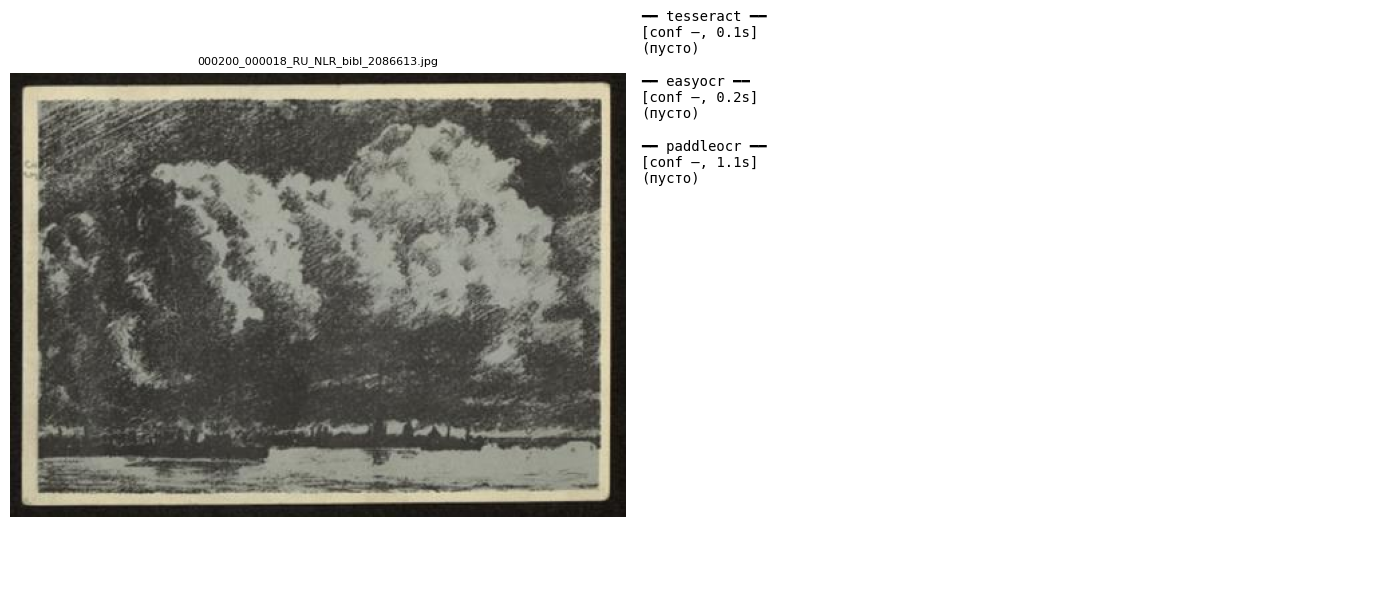

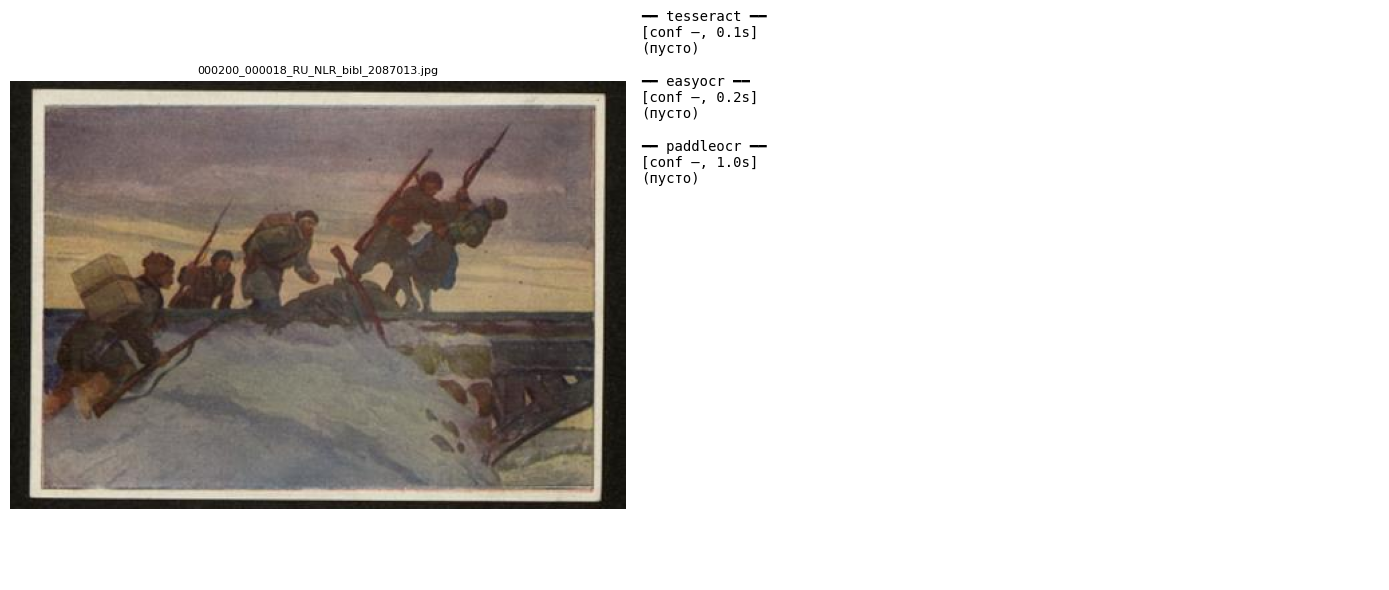

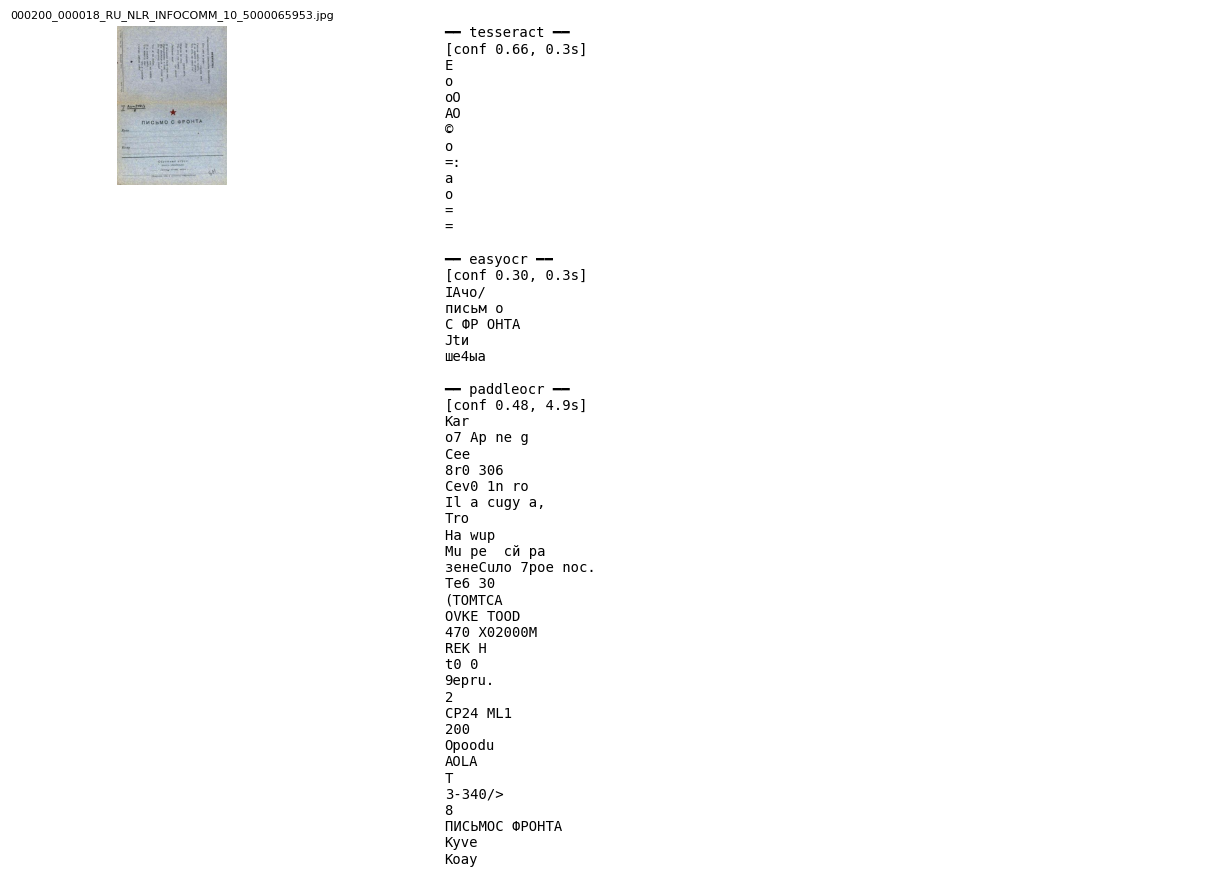

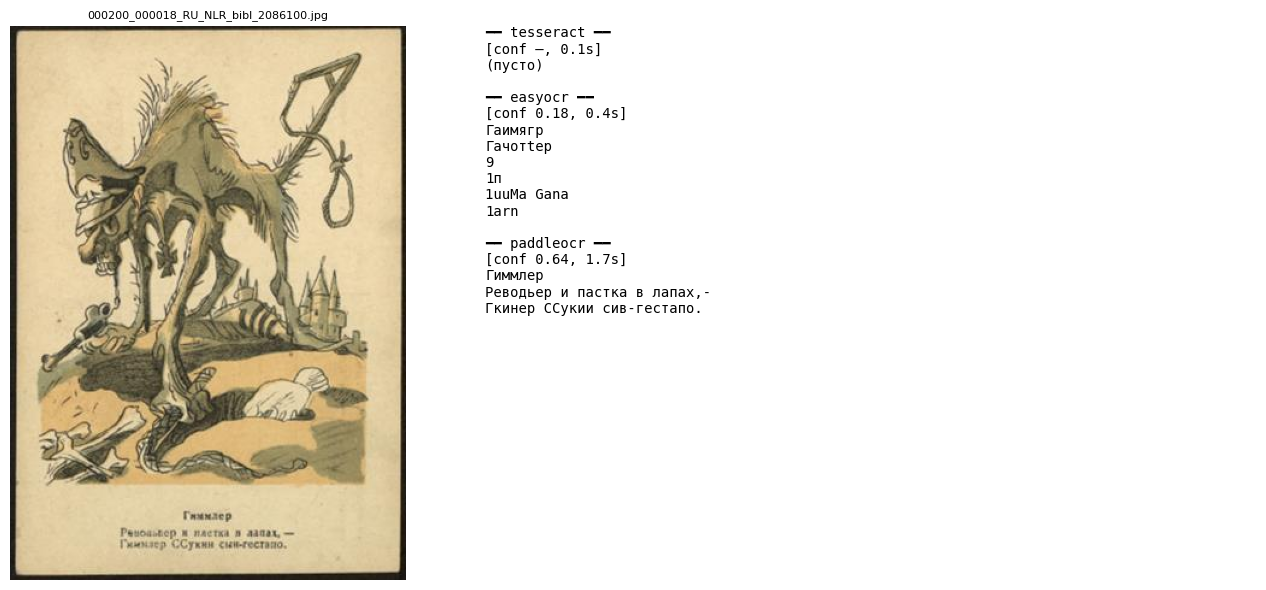

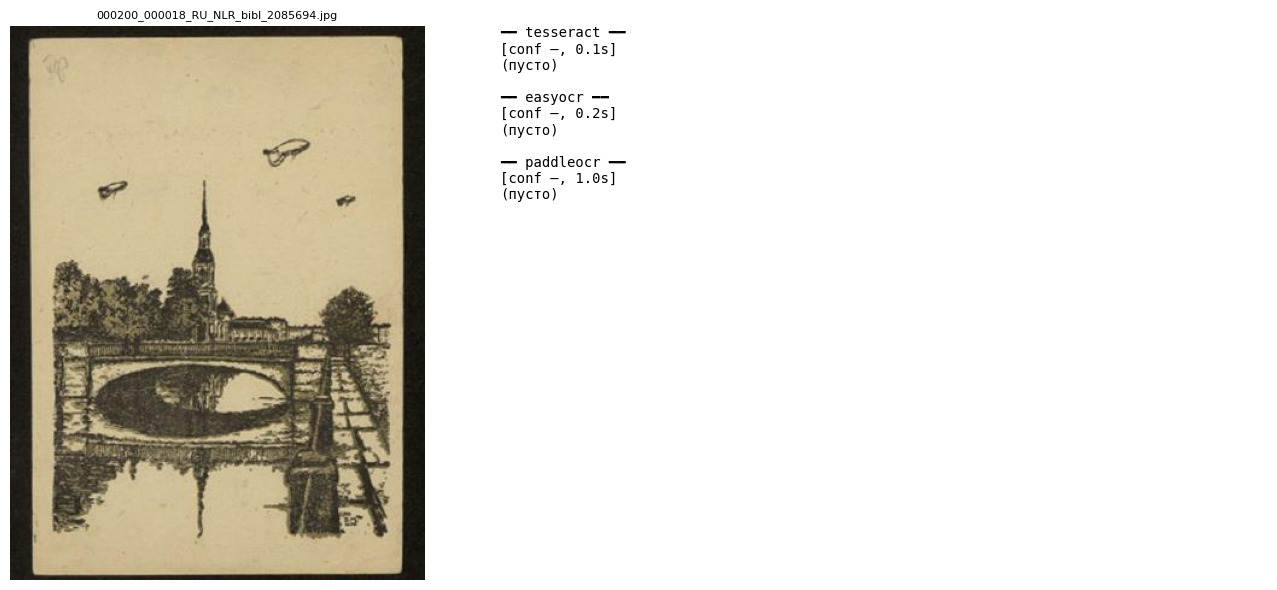

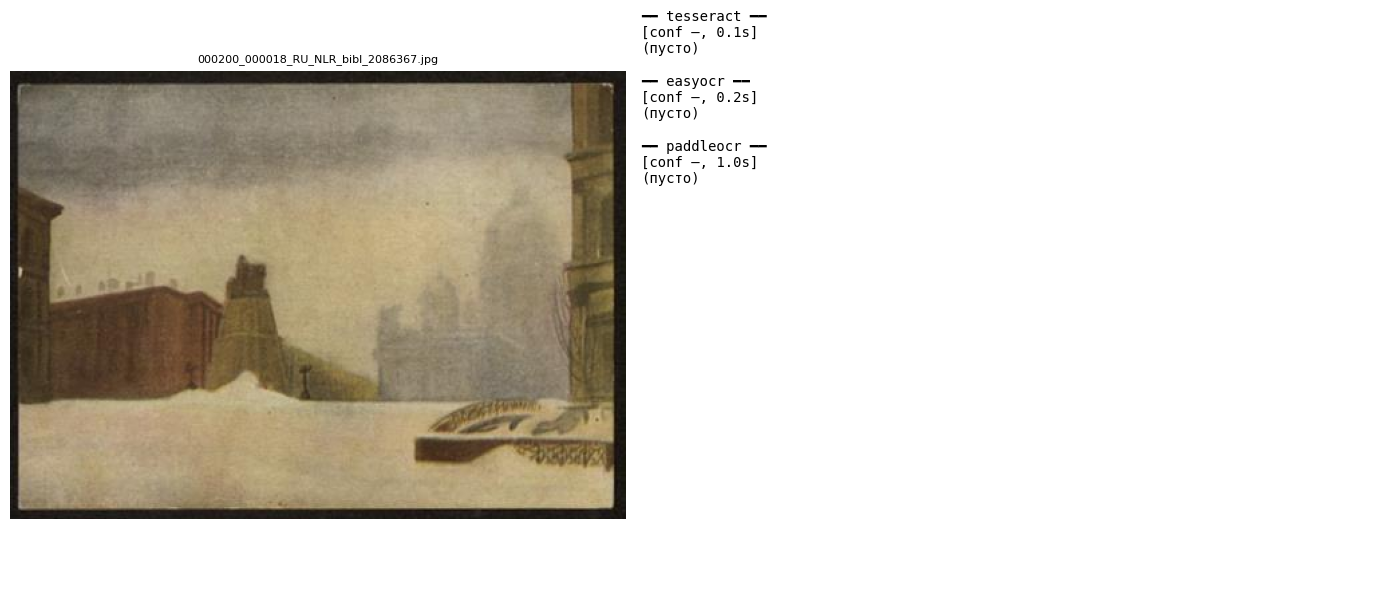

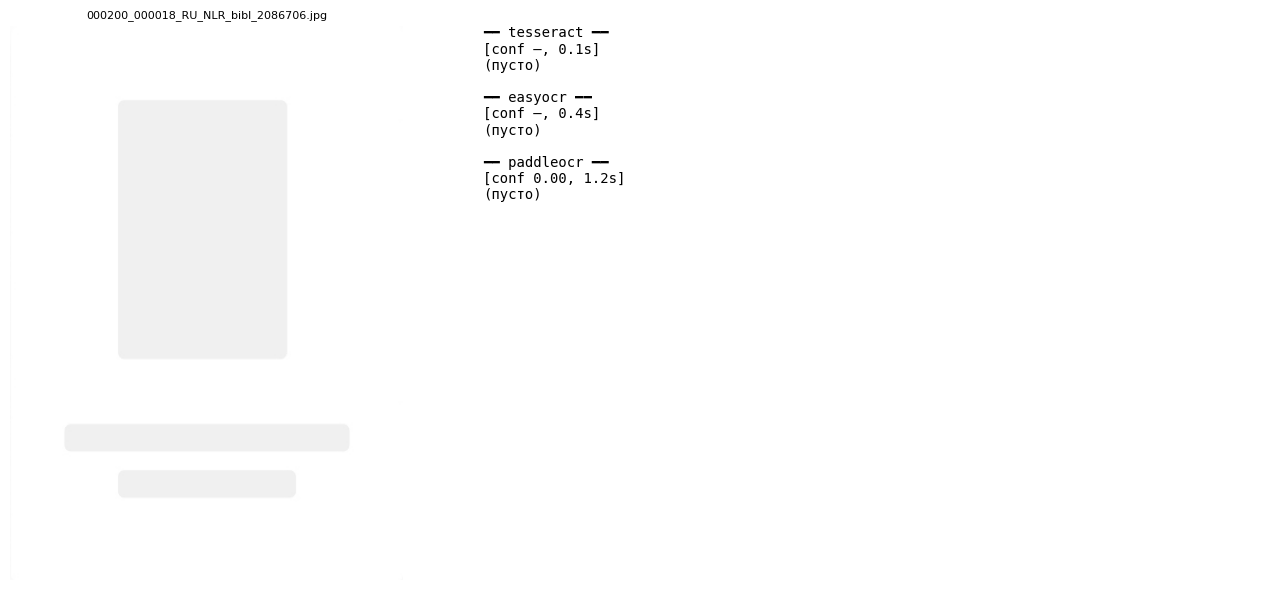

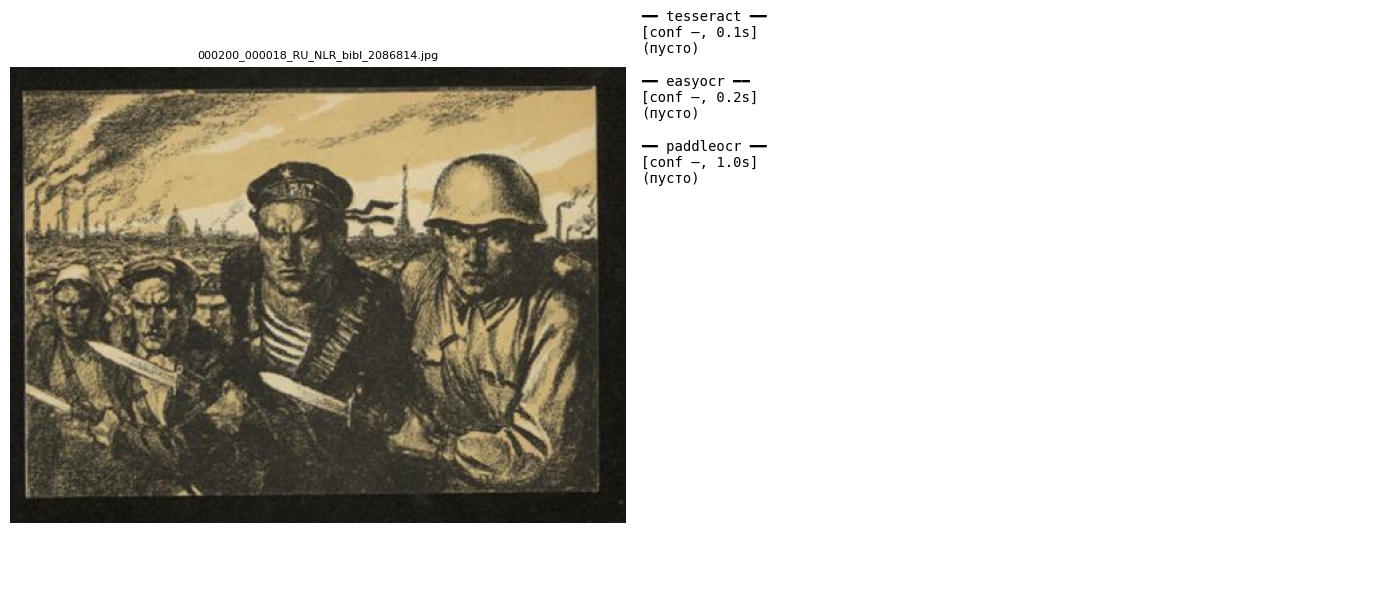

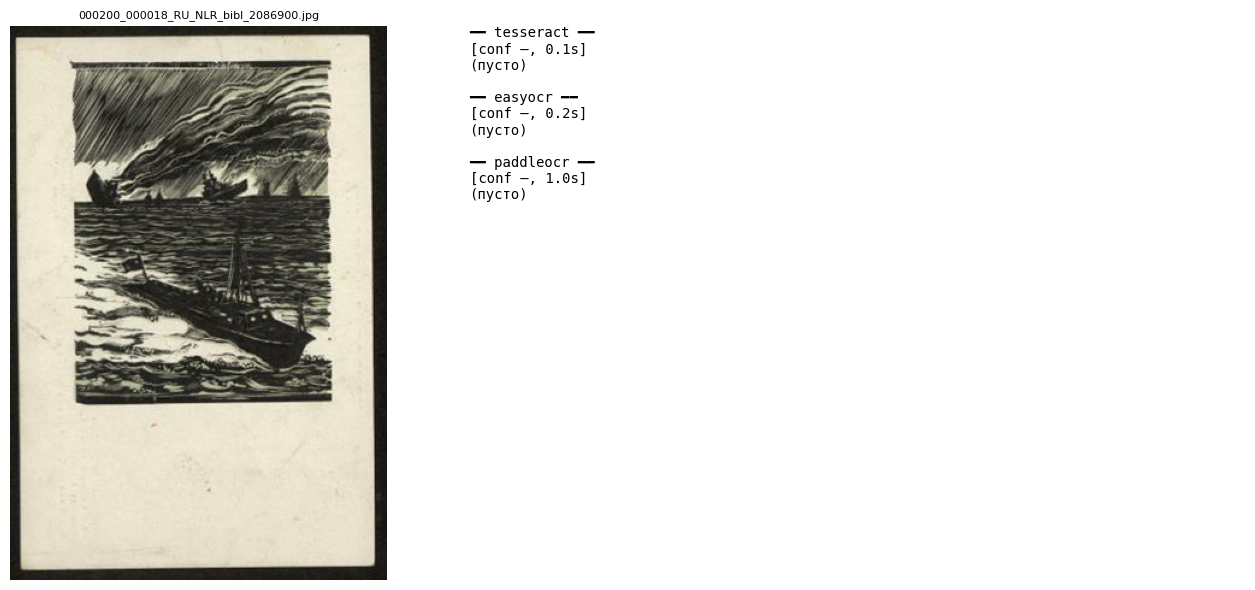

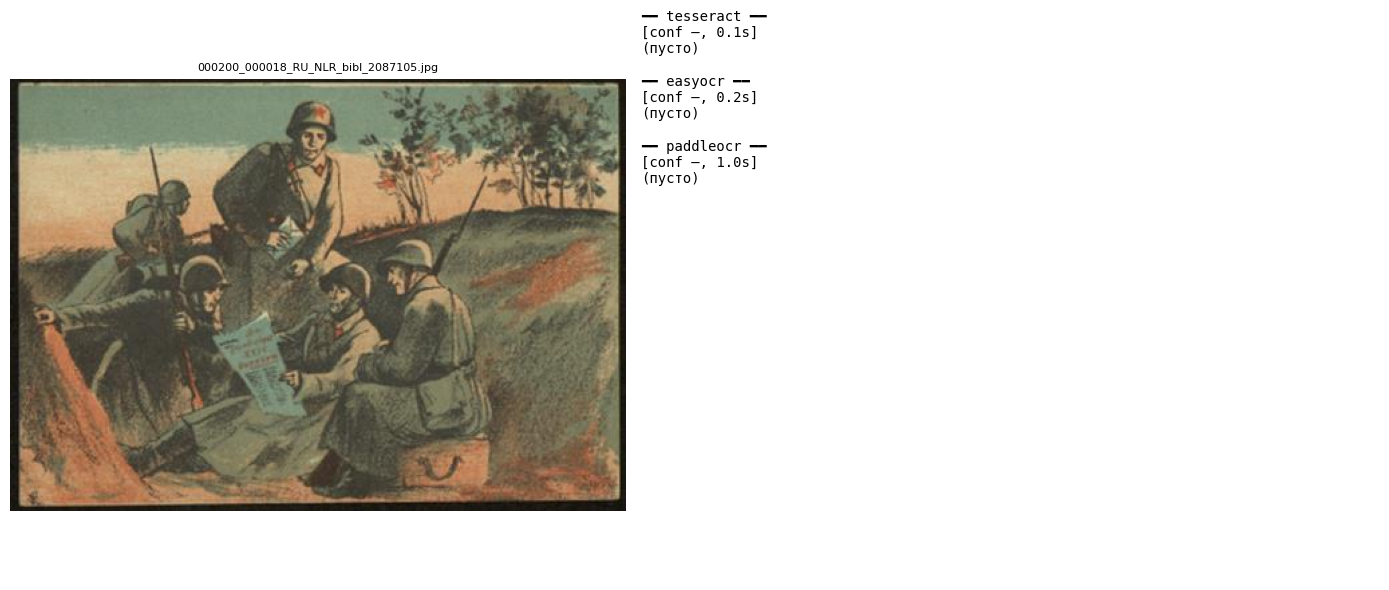

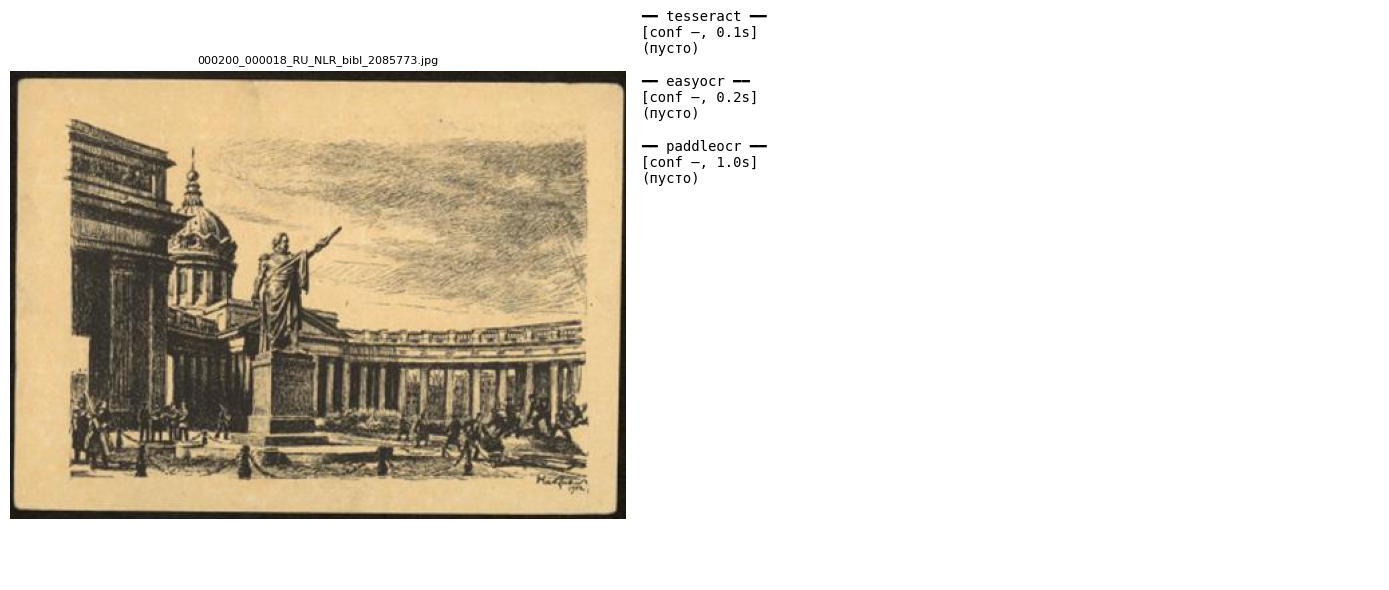

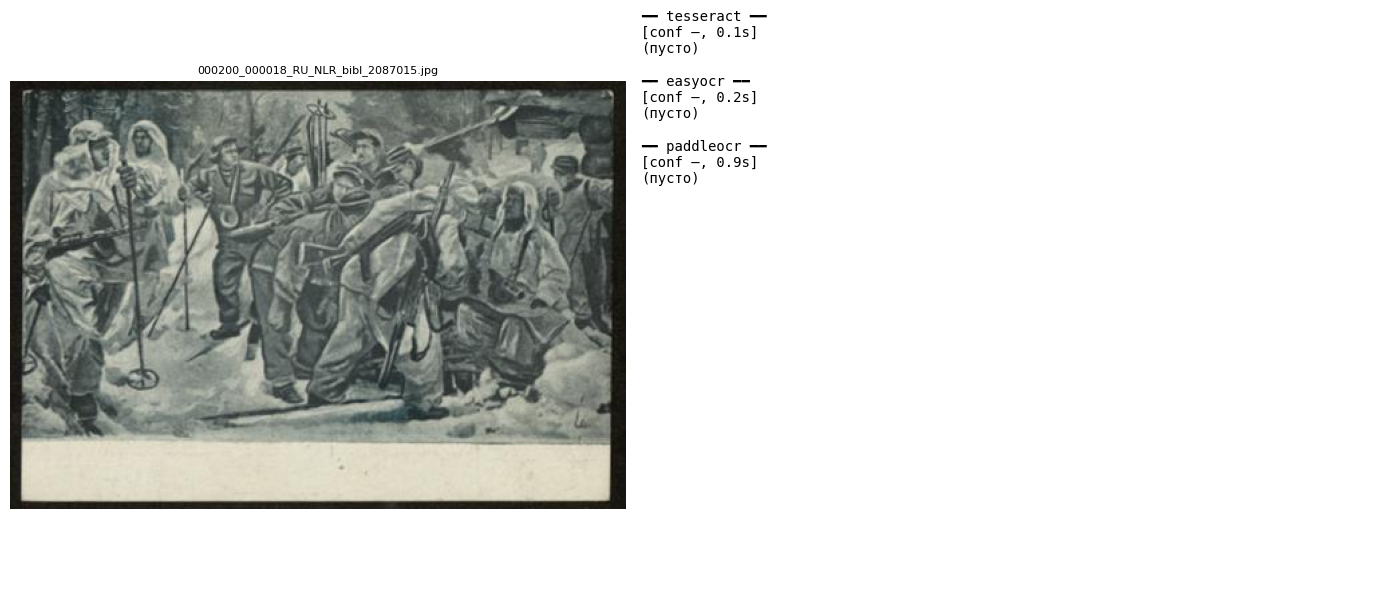

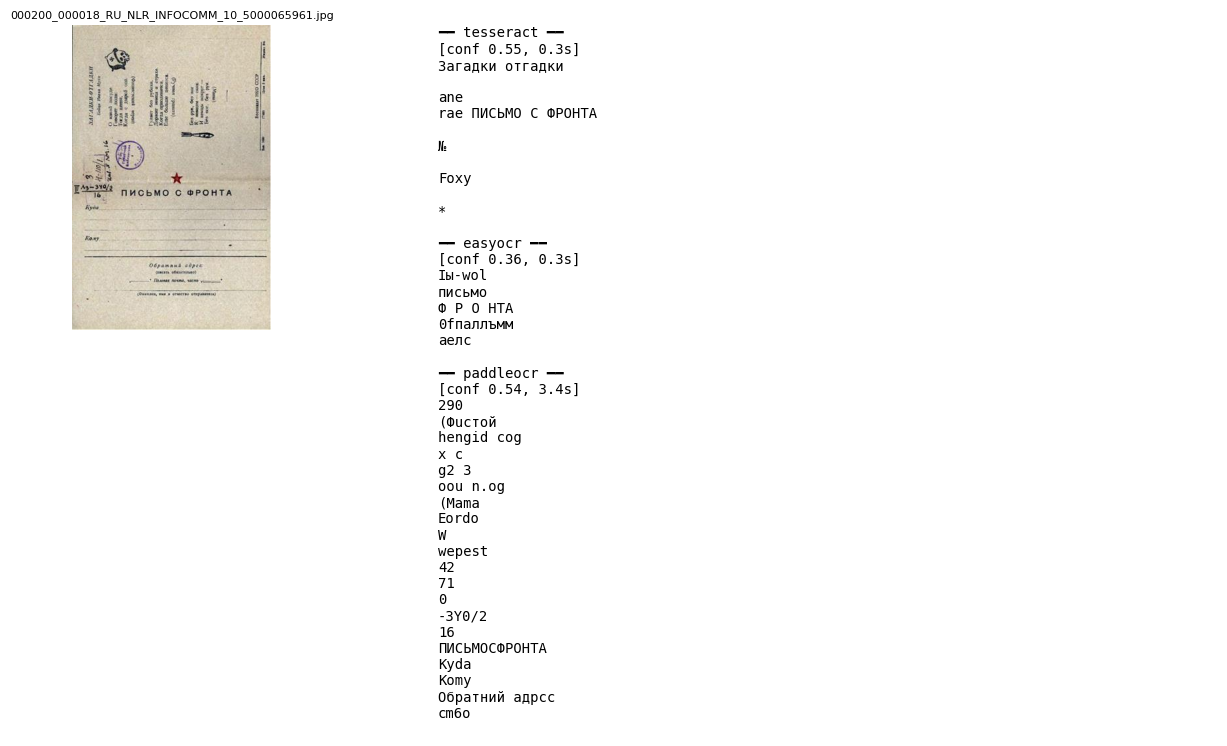

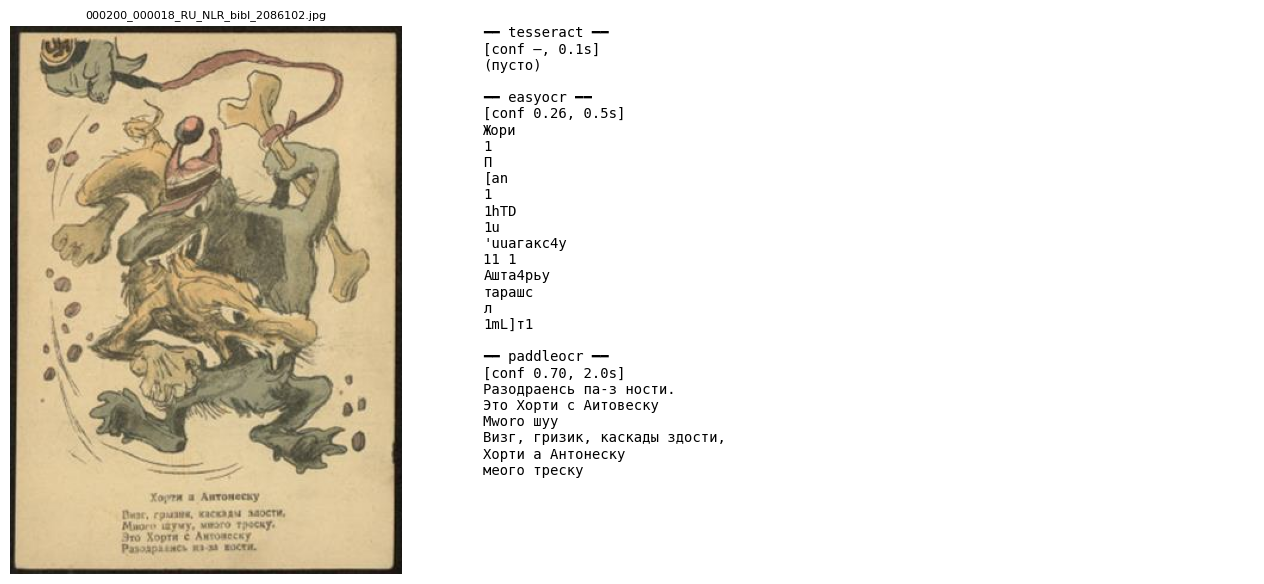

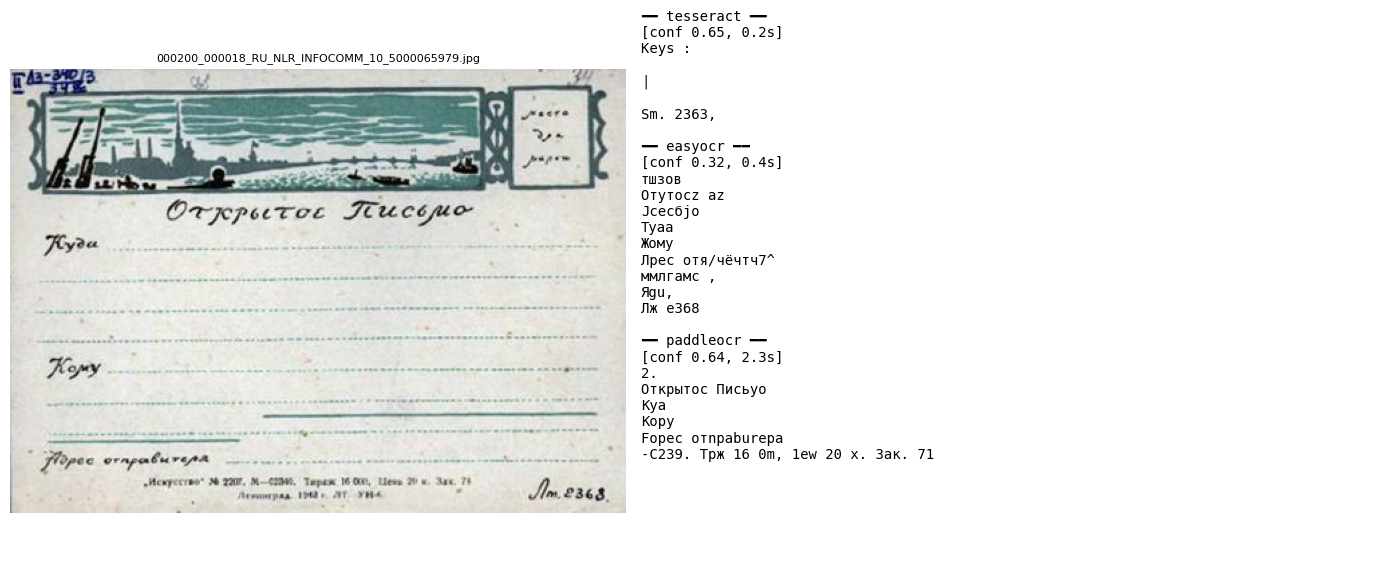

In [3]:
# корень проекта ищем независимо от рабочей директории ноутбука
def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data").is_dir() and (cand / "README.md").is_file():
            return cand
    raise RuntimeError("корень проекта не найден")

ROOT = find_root()
RESULTS = ROOT / "data/ocr_eval/ocr_neb_n15.json"   # или "data/ocr_eval/ocr_comparison.json"

data = json.loads(RESULTS.read_text(encoding="utf-8"))
images, engines = data["images"], data["engines"]

def text_for(engine_key, image_key):
    eng = engines.get(engine_key, {})
    if not eng.get("available"):
        return f"(движок недоступен: {eng.get('error')})"
    item = next((x for x in eng.get("per_image", []) if x["image"] == image_key), None)
    if item is None:
        return "(нет данных)"
    if item.get("error"):
        return f"(ошибка: {item['error']})"
    conf = item["confidence"]
    conf_s = f"{conf:.2f}" if conf is not None else "—"
    body = item["text"] or "(пусто)"
    body = "\n".join(textwrap.fill(ln, 50) for ln in body.splitlines())
    return f"[conf {conf_s}, {item['elapsed_sec']:.1f}s]\n{body}"

for img_key in images:                       # img_key — путь как в JSON (относительный)
    fig, ax = plt.subplots(1, 2, figsize=(14, 6),
                           gridspec_kw={"width_ratios": [1, 1.2]})
    ax[0].imshow(Image.open(ROOT / img_key).convert("RGB"))   # картинку резолвим от корня
    ax[0].axis("off")
    ax[0].set_title(Path(img_key).name, fontsize=8)

    blocks = [f"━━ {key} ━━\n{text_for(key, img_key)}\n" for key in engines]
    ax[1].axis("off")
    ax[1].text(0, 1, "\n".join(blocks), va="top", ha="left",
               fontsize=10, family="monospace")
    plt.tight_layout()
    plt.show()